In [ ]:
#Principal Component Analysis (PCA)

####Definition

Principal Component Analysis (PCA) is a dimensionality reduction technique used in statistics and machine learning that converts high-dimensional data into a smaller number of uncorrelated variables called principal components, while preserving as much information (variance) as possible.

####In simple words:
 PCA reduces the number of features without losing important information.

####Example (Real-Time, Simple)

####Problem:
A student dataset contains 4 subjects:

Maths

Physics

Chemistry

Biology

These subjects are highly correlated (students good in one subject tend to be good in others).

Issue:

Too many related features

Slower analysis

Hard to visualize

Solution using PCA:

PCA combines these 4 subjects into 2 principal components:

PC1 → Overall academic performance

PC2 → Science vs theory strength

Now:

Instead of 4 columns → only 2 components

Data becomes easier to analyze and visualize

Most information is still preserved

#### Another Practical Example (Data Science)

Before PCA:

Customer dataset with 50 features

Model is slow and complex

After PCA:

Reduced to 10 principal components

Model trains faster

Less noise

Better generalization

#### Key Points to Remember

PCA is unsupervised

PCA removes correlation

PCA keeps maximum variance

PCA improves speed and visualization

In [1]:
# Dataset: Iris

# Step 1: Import Required Libraries
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [57]:
# -----------------------------
# Step 2: Load Dataset
# -----------------------------
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print(target_names)
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y
df

['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [59]:
print('Dataset shape:',df.shape)

Dataset shape: (150, 5)


In [61]:
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [63]:
# step 3: Exploratory data analysis (EDA)

In [65]:
print("\nStatistical Summaey:\n")
print(df.describe())


Statistical Summaey:

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      Target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


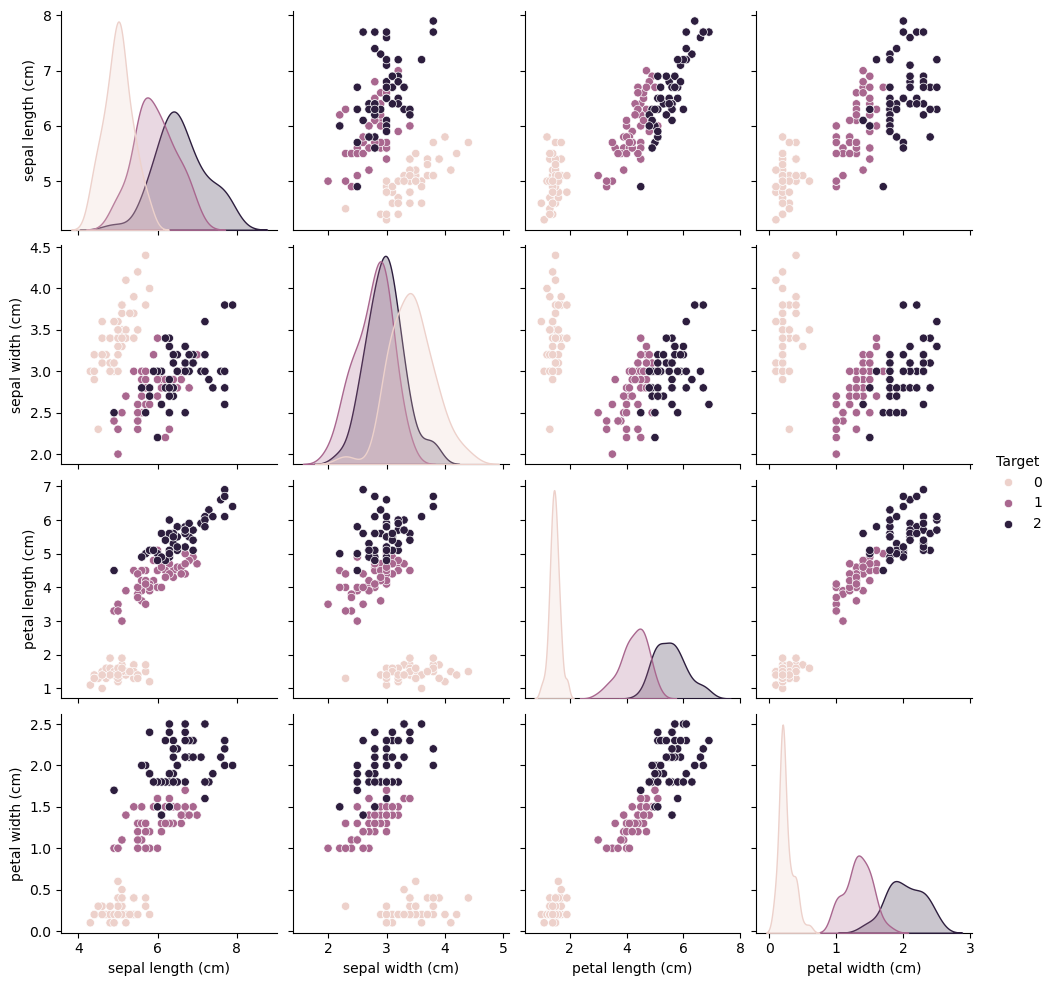

In [70]:
sns.pairplot(df,hue='Target')
plt.show()

In [71]:
# step4: feature scaling (important for pca)

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [72]:
# step5: apply pca

# reduce a dimension -> dimensions

pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_scaled)
X_pca

array([[-2.26470281,  0.4800266 , -0.12770602],
       [-2.08096115, -0.67413356, -0.23460885],
       [-2.36422905, -0.34190802,  0.04420148],
       [-2.29938422, -0.59739451,  0.09129011],
       [-2.38984217,  0.64683538,  0.0157382 ],
       [-2.07563095,  1.48917752,  0.02696829],
       [-2.44402884,  0.0476442 ,  0.3354704 ],
       [-2.23284716,  0.22314807, -0.0886955 ],
       [-2.33464048, -1.11532768,  0.14507686],
       [-2.18432817, -0.46901356, -0.25376557],
       [-2.1663101 ,  1.04369065, -0.2686811 ],
       [-2.32613087,  0.13307834,  0.09375924],
       [-2.2184509 , -0.72867617, -0.23091124],
       [-2.6331007 , -0.96150673,  0.18079608],
       [-2.1987406 ,  1.86005711, -0.472901  ],
       [-2.26221453,  2.68628449,  0.03052661],
       [-2.2075877 ,  1.48360936, -0.00534409],
       [-2.19034951,  0.48883832, -0.04421532],
       [-1.898572  ,  1.40501879, -0.37434327],
       [-2.34336905,  1.12784938,  0.13263047],
       [-1.914323  ,  0.40885571, -0.421

In [73]:
# create pca DataFrame

pca_df=pd.DataFrame(
    data=X_pca,
    columns=['Principal Component 1', 'Principal Component 2', 'Principal Component 3']
)

pca_df['Target']=y
pca_df

,Principal Component 1,Principal Component 2,Principal Component 3,Target
0,-2.264703,0.480027,-0.127706,0
1,-2.080961,-0.674134,-0.234609,0
2,-2.364229,-0.341908,0.044201,0
3,-2.299384,-0.597395,0.091290,0
4,-2.389842,0.646835,0.015738,0
...,...,...,...,...
145,1.870503,0.386966,0.256274,2
146,1.564580,-0.896687,-0.026371,2
147,1.521170,0.269069,0.180178,2
148,1.372788,1.011254,0.933395,2


In [74]:
print('\nExplained Variance Ratio:') # explained variance tells us how much information each principal component keeps.
print(pca.explained_variance_ratio_)



Explained Variance Ratio:
[0.72962445 0.22850762 0.03668922]


In [75]:
print('\nTotal Variance Explained:',  # total pca column importance sum
      np.sum(pca.explained_variance_ratio_))


Total Variance Explained: 0.9948212908928451


In [94]:
# plt.figure(figsize=(8,6))

# for target, color, label in zip([0,1,2],['red'],['green'],['blue'], target_names):
#     plt.scatter(
#         pca_df[pca_df['Target']==target]['Principal Component 1'],
#         pca_df[pca_df['Target']==target['Principal Component 2']],
#         color=color,
#         label=label
#     )

# plt.xlabel('Principal Component 1')
# plt.ylabel('Principal Component 2')
# plt.title('PCA - 2D Projection of Iris Dataset')
# plt.legend()
# plt.grid()
# plt.show()

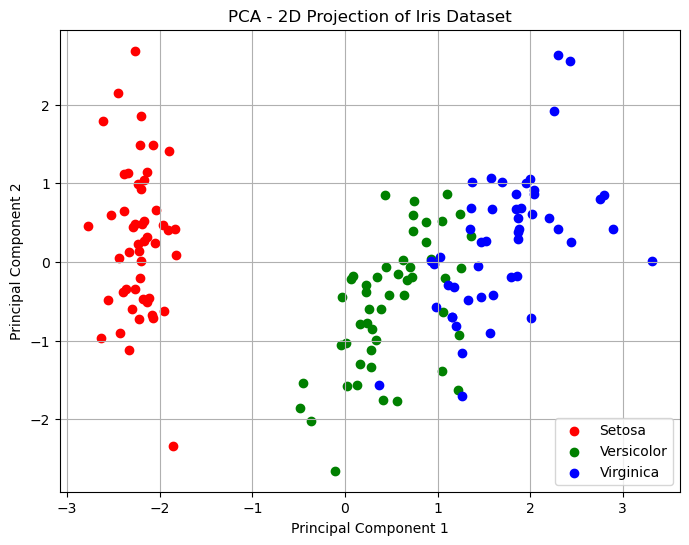

In [96]:
plt.figure(figsize=(8,6))

target_names = ['Setosa', 'Versicolor', 'Virginica']
colors = ['red', 'green', 'blue']

for target, color, label in zip([0,1,2], colors, target_names):
    plt.scatter(
        pca_df[pca_df['Target'] == target]['Principal Component 1'],
        pca_df[pca_df['Target'] == target]['Principal Component 2'],
        color=color,
        label=label
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - 2D Projection of Iris Dataset')
plt.legend()
plt.grid()
plt.show()

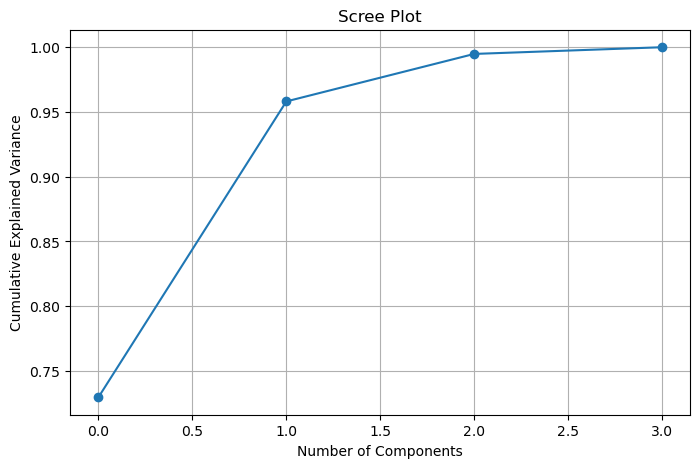

In [100]:
# step 7 : Scree plot (variance explanation)

pca_full=PCA()
pca_full.fit(X_scaled)

plt.figure(figsize=(8,5))
plt.plot(
    np.cumsum(pca_full.explained_variance_ratio_),
    marker='o'
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.grid()
plt.show()


In [102]:
# step 8: PCA components loadings

loadings=pd.DataFrame(
    pca.components_.T,
    columns=['PC1','PC2','PC3'],
    index=feature_names
)

print('\nPCA feature loadings:\n')
print(loadings)



PCA feature loadings:

                        PC1       PC2       PC3
sepal length (cm)  0.521066  0.377418 -0.719566
sepal width (cm)  -0.269347  0.923296  0.244382
petal length (cm)  0.580413  0.024492  0.142126
petal width (cm)   0.564857  0.066942  0.634273
